# 🧹 Vezilka Dataset — Cleaning & Filtering

This notebook loads the **original** `vezilka_mk_sq.tsv`, applies quality filters,
fixes known encoding issues, and exports a **new cleaned dataset** without modifying the original.

### Cleaning steps:
1. Fix backtick encoding (`` ` `` → `ë`) in Albanian text
2. Fix hyphenated line-breaks in Macedonian text (`Ар - мијата` → `Армијата`)
3. Remove rows with hex hashes leaked into text
4. Remove rows that fail script validation (MK not Cyrillic / SQ not Latin)
5. Remove very short sentences (< 5 words)
6. Remove extreme length ratios (MK/SQ ratio outside 0.3–3.0)
7. Discard low-confidence pairs (configurable threshold)
8. Remove near-duplicate pairs
9. Export cleaned dataset to new TSV

In [1]:
import pandas as pd
import numpy as np
import re
import hashlib
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['figure.figsize'] = (14, 5)
plt.style.use('seaborn-v0_8-whitegrid')

# ── Paths ──
ORIGINAL_TSV = 'data/export/vezilka_mk_sq.tsv'
CLEANED_TSV  = 'data/export/vezilka_mk_sq_cleaned.tsv'

# ── Configurable thresholds ──
MIN_CONFIDENCE  = 0.60      # discard pairs below this confidence
MIN_WORDS       = 5         # minimum words per sentence (both sides)
MAX_WORDS       = 200       # maximum words per sentence
MIN_RATIO       = 0.3       # min MK/SQ word ratio
MAX_RATIO       = 3.0       # max MK/SQ word ratio
CYRILLIC_THRESH = 0.50      # MK text must be at least this % Cyrillic
LATIN_THRESH    = 0.50      # SQ text must be at least this % Latin

print('✓ Config loaded')
print(f'  MIN_CONFIDENCE = {MIN_CONFIDENCE}')
print(f'  MIN_WORDS      = {MIN_WORDS}')
print(f'  MAX_WORDS      = {MAX_WORDS}')
print(f'  WORD RATIO     = [{MIN_RATIO}, {MAX_RATIO}]')
print(f'  CYRILLIC_THRESH= {CYRILLIC_THRESH}')
print(f'  LATIN_THRESH   = {LATIN_THRESH}')

✓ Config loaded
  MIN_CONFIDENCE = 0.6
  MIN_WORDS      = 5
  MAX_WORDS      = 200
  WORD RATIO     = [0.3, 3.0]
  CYRILLIC_THRESH= 0.5
  LATIN_THRESH   = 0.5


## 1. Load Original Dataset

In [2]:
original = pd.read_csv(ORIGINAL_TSV, sep='\t', quoting=3)
print(f'Original dataset: {len(original):,} rows')
print(f'Columns: {list(original.columns)}')
original.head(3)

Original dataset: 100,897 rows
Columns: ['mk', 'sq', 'source', 'article_id', 'confidence', 'method']


,mk,sq,source,article_id,confidence,method
0,"увоз - извоз - Блатец - Виница , со земјоделск...",Republika e Maqedonisë hyri në borxh ndaj Bank...,5DEEADB1E363224EAF2DFA137F40E518,1,0.885,structural+gc_2-1
1,Со оваа одлука престанува правото на користење...,Afati për pagesës së kreditit prej nenit 1 të ...,5DEEADB1E363224EAF2DFA137F40E518,2,0.888,structural+gc_1-1
2,увоз - извоз - Блатец - Ви - ница .,Pas efikasitetit të kreditit do të pagohet pro...,5DEEADB1E363224EAF2DFA137F40E518,2,0.436,structural+gc_1-1


In [3]:
# Work on a copy — never touch the original DataFrame after this
df = original.copy()
df['mk'] = df['mk'].astype(str)
df['sq'] = df['sq'].astype(str)
df['confidence'] = pd.to_numeric(df['confidence'], errors='coerce')

# We'll track every removal reason
df['_remove'] = False
df['_reason'] = ''
removal_log = {}  # reason -> count

def flag_removal(mask, reason):
    """Flag rows for removal. Only flags rows not already flagged."""
    new_flags = mask & ~df['_remove']
    count = new_flags.sum()
    df.loc[new_flags, '_remove'] = True
    df.loc[new_flags, '_reason'] = reason
    removal_log[reason] = count
    print(f'  ✗ {reason}: {count:,} rows flagged')
    return count

print(f'Working copy ready: {len(df):,} rows')

Working copy ready: 100,897 rows


## 2. Fix Known Encoding Issues (repair, don't discard)

In [4]:
# ── Fix 1: Backtick → ë in Albanian text ──
# Older PDFs encode the Albanian 'ë' as backtick (`) due to font mapping issues
backtick_before = df['sq'].str.contains('`', regex=False).sum()
df['sq'] = df['sq'].str.replace('`', 'ë', regex=False)
backtick_after = df['sq'].str.contains('`', regex=False).sum()
print(f'Fix backtick→ë:  {backtick_before:,} rows affected, {backtick_after} remaining')

# Show a before/after example
if backtick_before > 0:
    idx = original['sq'].astype(str).str.contains('`', regex=False).idxmax()
    print(f'\n  BEFORE: {original.at[idx, "sq"][:120]}')
    print(f'  AFTER:  {df.at[idx, "sq"][:120]}')

Fix backtick→ë:  219 rows affected, 0 remaining

  BEFORE: Me k`t` ligj rregullohet statusi, t` drejtat, detyrat dhe p`rgjegjsit` e personave n` sh`rbim, n` Armat`n e Republik`s s
  AFTER:  Me këtë ligj rregullohet statusi, të drejtat, detyrat dhe përgjegjsitë e personave në shërbim, në Armatën e Republikës s


In [5]:
# ── Fix 2: Hyphenated line-breaks in Macedonian ──
# PDF extraction creates "Ар - мијата" from "Армијата" when words break across lines
# Pattern: Cyrillic/Latin chars + space + hyphen + space + lowercase continuation

def fix_hyphen_breaks(text):
    """Rejoin words split by line-break hyphens: 'Ар - мијата' → 'Армијата'"""
    # Cyrillic hyphen-break: word - continuation (lowercase Cyrillic)
    text = re.sub(r'(\w) - ([а-яё])', r'\1\2', text)
    # Latin hyphen-break: word - continuation (lowercase Latin) 
    text = re.sub(r'(\w) - ([a-zëç])', r'\1\2', text)
    return text

hyphen_before_mk = df['mk'].str.contains(r'\w - [а-яa-z]', regex=True).sum()
hyphen_before_sq = df['sq'].str.contains(r'\w - [а-яa-zëç]', regex=True).sum()

df['mk'] = df['mk'].apply(fix_hyphen_breaks)
df['sq'] = df['sq'].apply(fix_hyphen_breaks)

hyphen_after_mk = df['mk'].str.contains(r'\w - [а-яa-z]', regex=True).sum()
hyphen_after_sq = df['sq'].str.contains(r'\w - [а-яa-zëç]', regex=True).sum()

print(f'Fix hyphen-breaks (MK): {hyphen_before_mk:,} → {hyphen_after_mk:,} rows with pattern')
print(f'Fix hyphen-breaks (SQ): {hyphen_before_sq:,} → {hyphen_after_sq:,} rows with pattern')

# Show example
if hyphen_before_mk > 0:
    idx = original['mk'].astype(str).str.contains(r'\w - [а-я]', regex=True).idxmax()
    print(f'\n  BEFORE: {original.at[idx, "mk"][:120]}')
    print(f'  AFTER:  {df.at[idx, "mk"][:120]}')

Fix hyphen-breaks (MK): 35,282 → 4 rows with pattern
Fix hyphen-breaks (SQ): 4,944 → 0 rows with pattern

  BEFORE: увоз - извоз - Блатец - Виница , со земјоделско земјиште во вкупна површина 2 од 4.520 м кое претставува КП 722 во површ
  AFTER:  увозизвоз - Блатец - Виница , со земјоделско земјиште во вкупна површина 2 од 4.520 м кое претставува КП 722 во површина


## 3. Flag Rows for Removal

In [6]:
# ── Filter 1: Low confidence ──
print(f'\n=== Flagging bad rows (thresholds shown in cell 2) ===\n')

flag_removal(
    df['confidence'] < MIN_CONFIDENCE,
    f'low_confidence(<{MIN_CONFIDENCE})'
)


=== Flagging bad rows (thresholds shown in cell 2) ===

  ✗ low_confidence(<0.6): 3,008 rows flagged


3008

In [7]:
# ── Filter 2: Sentence length ──
df['mk_words'] = df['mk'].apply(lambda x: len(x.split()))
df['sq_words'] = df['sq'].apply(lambda x: len(x.split()))

flag_removal(
    (df['mk_words'] < MIN_WORDS) | (df['sq_words'] < MIN_WORDS),
    f'too_short(<{MIN_WORDS}_words)'
)

flag_removal(
    (df['mk_words'] > MAX_WORDS) | (df['sq_words'] > MAX_WORDS),
    f'too_long(>{MAX_WORDS}_words)'
)

  ✗ too_short(<5_words): 6,402 rows flagged
  ✗ too_long(>200_words): 6,402 rows flagged


6402

In [8]:
# ── Filter 3: Length ratio ──
df['word_ratio'] = df['mk_words'] / df['sq_words'].replace(0, np.nan)

flag_removal(
    (df['word_ratio'] < MIN_RATIO) | (df['word_ratio'] > MAX_RATIO),
    f'bad_length_ratio(outside_{MIN_RATIO}-{MAX_RATIO})'
)

  ✗ bad_length_ratio(outside_0.3-3.0): 45 rows flagged


45

In [9]:
# ── Filter 4: Script validation ──
# MK sentences should be predominantly Cyrillic, SQ predominantly Latin

def cyrillic_ratio(text):
    cyr = sum(1 for c in text if '\u0400' <= c <= '\u04FF')
    alpha = sum(1 for c in text if c.isalpha())
    return cyr / alpha if alpha > 0 else 0.0

def latin_ratio(text):
    lat = sum(1 for c in text if ('A' <= c <= 'Z') or ('a' <= c <= 'z') or c in 'ëçËÇ')
    alpha = sum(1 for c in text if c.isalpha())
    return lat / alpha if alpha > 0 else 0.0

print('Computing script ratios (this may take ~30s)...')
df['mk_cyr'] = df['mk'].apply(cyrillic_ratio)
df['sq_lat'] = df['sq'].apply(latin_ratio)

flag_removal(
    df['mk_cyr'] < CYRILLIC_THRESH,
    f'mk_not_cyrillic(<{CYRILLIC_THRESH})'
)

flag_removal(
    df['sq_lat'] < LATIN_THRESH,
    f'sq_not_latin(<{LATIN_THRESH})'
)
print('Done.')

Computing script ratios (this may take ~30s)...
  ✗ mk_not_cyrillic(<0.5): 13 rows flagged
  ✗ sq_not_latin(<0.5): 14 rows flagged
Done.


In [10]:
# ── Filter 5: Hex hashes leaked into text ──
flag_removal(
    df['mk'].str.contains(r'[A-F0-9]{32}', regex=True) |
    df['sq'].str.contains(r'[A-F0-9]{32}', regex=True),
    'hex_hash_in_text'
)

  ✗ hex_hash_in_text: 0 rows flagged


0

In [11]:
# ── Filter 6: Mostly numbers / not real text ──
def number_fraction(text):
    words = text.split()
    if not words:
        return 1.0
    nums = sum(1 for w in words if re.fullmatch(r'[\d.,/%]+', w))
    return nums / len(words)

df['mk_numfrac'] = df['mk'].apply(number_fraction)
df['sq_numfrac'] = df['sq'].apply(number_fraction)

flag_removal(
    (df['mk_numfrac'] > 0.5) | (df['sq_numfrac'] > 0.5),
    'mostly_numbers(>50%)'
)

  ✗ mostly_numbers(>50%): 130 rows flagged


130

In [12]:
# ── Filter 7: Exact duplicates ──
def pair_hash(row):
    combined = row['mk'].strip().lower() + ' ||| ' + row['sq'].strip().lower()
    return hashlib.sha256(combined.encode('utf-8')).hexdigest()

df['_hash'] = df.apply(pair_hash, axis=1)
dup_mask = df.duplicated(subset='_hash', keep='first')
flag_removal(dup_mask, 'exact_duplicate')

  ✗ exact_duplicate: 1,099 rows flagged


1099

## 4. Removal Summary

In [13]:
total_removed = df['_remove'].sum()
total_kept = len(df) - total_removed

print('╔══════════════════════════════════════════════════════════════╗')
print('║              CLEANING SUMMARY                              ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  Original rows:          {len(df):>8,}                        ║')
print(f'║  Rows flagged for removal:{total_removed:>7,}                        ║')
print(f'║  Rows kept:              {total_kept:>8,}  ({total_kept/len(df)*100:.1f}%)              ║')
print('╠══════════════════════════════════════════════════════════════╣')

for reason, count in sorted(removal_log.items(), key=lambda x: -x[1]):
    pct = count / len(df) * 100
    print(f'║  {reason:<34s} {count:>6,}  ({pct:>5.2f}%)    ║')

print('╚══════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════╗
║              CLEANING SUMMARY                              ║
╠══════════════════════════════════════════════════════════════╣
║  Original rows:           100,897                        ║
║  Rows flagged for removal: 17,113                        ║
║  Rows kept:                83,784  (83.0%)              ║
╠══════════════════════════════════════════════════════════════╣
║  too_short(<5_words)                 6,402  ( 6.35%)    ║
║  too_long(>200_words)                6,402  ( 6.35%)    ║
║  low_confidence(<0.6)                3,008  ( 2.98%)    ║
║  exact_duplicate                     1,099  ( 1.09%)    ║
║  mostly_numbers(>50%)                  130  ( 0.13%)    ║
║  bad_length_ratio(outside_0.3-3.0)      45  ( 0.04%)    ║
║  sq_not_latin(<0.5)                     14  ( 0.01%)    ║
║  mk_not_cyrillic(<0.5)                  13  ( 0.01%)    ║
║  hex_hash_in_text                        0  ( 0.00%)    ║
╚═══════════════════

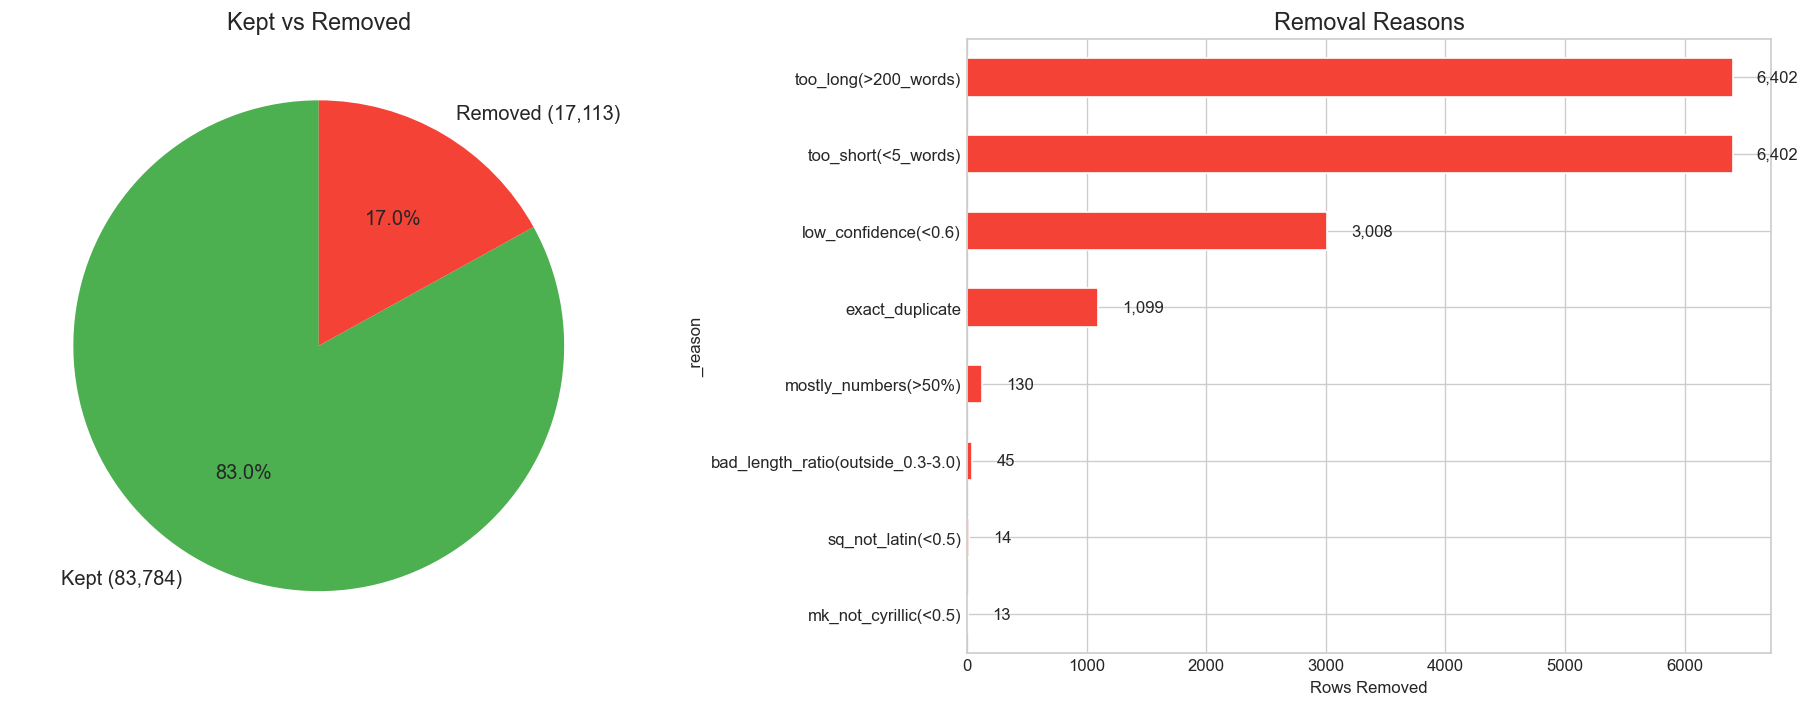

In [14]:
# Visual breakdown
reasons = df[df['_remove']]['_reason'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie: kept vs removed
axes[0].pie(
    [total_kept, total_removed],
    labels=[f'Kept ({total_kept:,})', f'Removed ({total_removed:,})'],
    colors=['#4CAF50', '#F44336'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12}
)
axes[0].set_title('Kept vs Removed', fontsize=14)

# Bar: removal reasons
reasons.plot.barh(ax=axes[1], color='#F44336', edgecolor='white')
axes[1].set_xlabel('Rows Removed')
axes[1].set_title('Removal Reasons', fontsize=14)
axes[1].invert_yaxis()
for i, v in enumerate(reasons.values):
    axes[1].text(v + len(df)*0.002, i, f'{v:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 5. Inspect Removed Rows — Spot Check

In [15]:
# Show a few examples from each removal reason
for reason in removal_log:
    subset = df[df['_reason'] == reason]
    if len(subset) == 0:
        continue
    sample = subset.sample(n=min(2, len(subset)), random_state=42)
    print(f'\n── {reason} ({len(subset):,} rows) ──')
    for _, row in sample.iterrows():
        print(f'  MK: {row["mk"][:100]}')
        print(f'  SQ: {row["sq"][:100]}')
        print(f'  conf={row["confidence"]}  method={row["method"]}')
        print()


── low_confidence(<0.6) (3,008 rows) ──
  MK: Членот 12 се брише .
  SQ: Në nenin 53 paragrafi (5) fjala “parregullsi” zëvendësohet me fjalën ”paligjshmëri”, fjala “shoqëri”
  conf=0.433  method=structural+gc_1-1

  MK: Образецот бр . 2 за евиденција на прекршочните предмети за правни лицаконтролори / обработувачи , со
  SQ: Në nenin 6 shtohet paragraf i ri (2), si vijon: “(2) Shtetasit e Republikës së Maqedonisë të cilët n
  conf=0.537  method=structural+gc_1-1


── too_short(<5_words) (6,402 rows) ──
  MK: ПОСЕБНИ МЕРКИ НА БЕЗБЕДНОСТ
  SQ: MASA TË VEÇANTA TË SIGURIMIT
  conf=0.919  method=structural+gc_1-1

  MK: Вработување на помошно – технички персонал
  SQ: Punësimi i personelit ndihmësteknik
  conf=0.884  method=structural+gc_1-1


── too_long(>200_words) (6,402 rows) ──
  MK: Корисникот , кој со решение на центарот остварил право на сместување во згрижувачко семејство , прав
  SQ: Shfrytëzuesi, i cili me aktvendim nga qendra ka realizuar të drejtën për vendosje në familje përk

## 6. Build the Cleaned Dataset

In [16]:
# Keep only rows that passed all filters
clean = df[~df['_remove']].copy()

# Drop internal helper columns
helper_cols = [c for c in clean.columns if c.startswith('_') or c in 
               ['mk_words', 'sq_words', 'word_ratio', 'mk_cyr', 'sq_lat', 'mk_numfrac', 'sq_numfrac']]
clean = clean.drop(columns=helper_cols, errors='ignore')

# Strip whitespace
clean['mk'] = clean['mk'].str.strip()
clean['sq'] = clean['sq'].str.strip()

print(f'Cleaned dataset: {len(clean):,} rows (from {len(original):,} original)')
print(f'Columns: {list(clean.columns)}')
clean.head(5)

Cleaned dataset: 83,784 rows (from 100,897 original)
Columns: ['mk', 'sq', 'source', 'article_id', 'confidence', 'method']


,mk,sq,source,article_id,confidence,method
0,"увозизвоз - Блатец - Виница , со земјоделско з...",Republika e Maqedonisë hyri në borxh ndaj Bank...,5DEEADB1E363224EAF2DFA137F40E518,1,0.885,structural+gc_2-1
1,Со оваа одлука престанува правото на користење...,Afati për pagesës së kreditit prej nenit 1 të ...,5DEEADB1E363224EAF2DFA137F40E518,2,0.888,structural+gc_1-1
3,Договорот за замена на правото на сопственост ...,Shfrytëzuesi i fundit të kreditit është Drejto...,5DEEADB1E363224EAF2DFA137F40E518,3,0.899,structural+gc_1-1
4,"бр . 765/2002, од 11.03.2002 година , во регис...",Krediti prej nenit 1 të këtij ligji do ta pago...,5DEEADB1E363224EAF2DFA137F40E518,4,0.930,structural+gc_2-1
5,Субјектите наследници на Управата за Цивилна в...,Subjektet trashëgimtare e Drejtorisë së lundri...,5DEEADB1E363224EAF2DFA137F40E518,5,0.897,structural+gc_1-1


## 7. Compare Original vs Cleaned

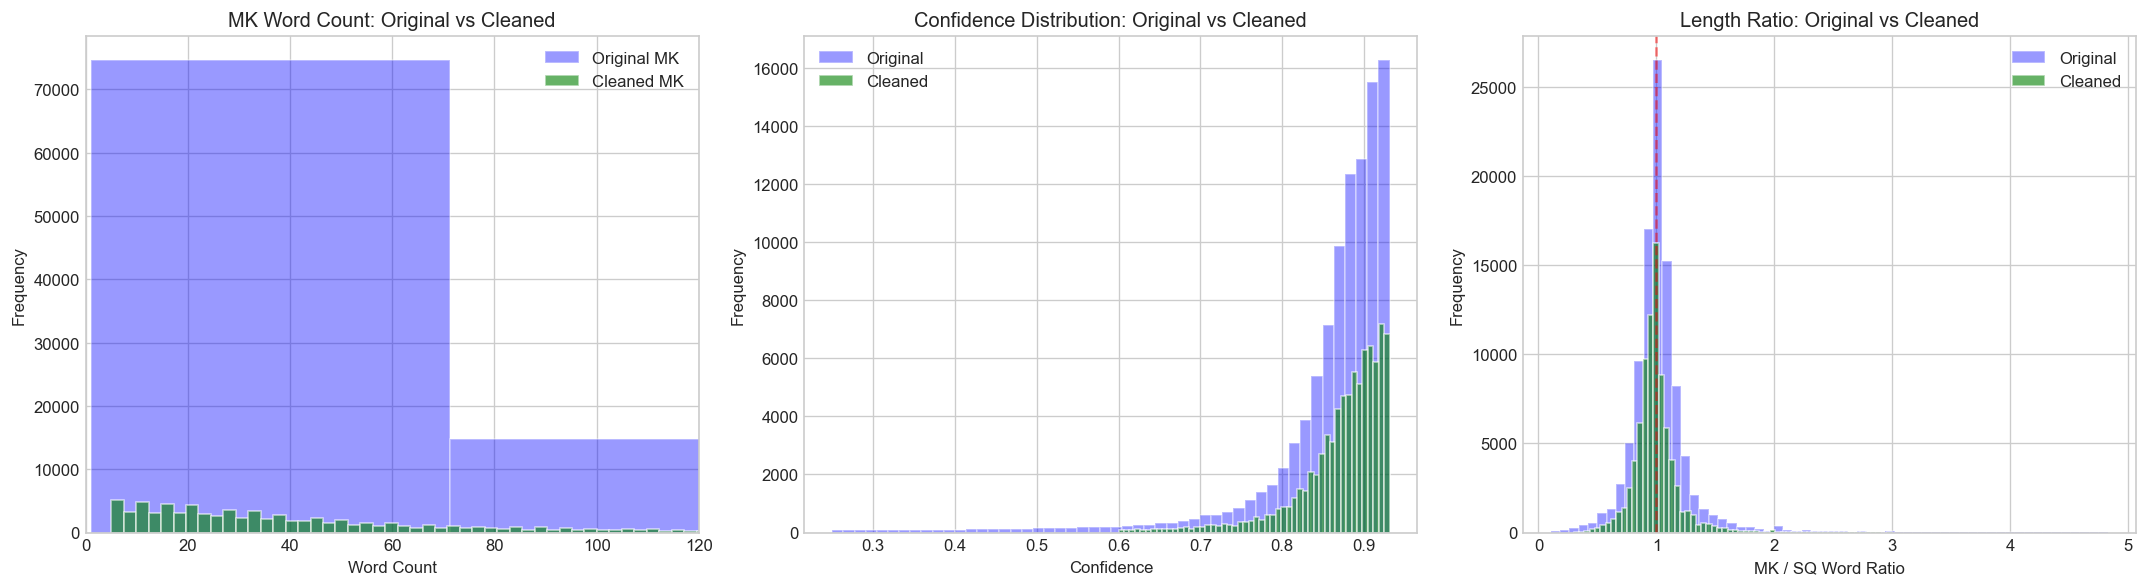

In [17]:
clean['mk_words'] = clean['mk'].apply(lambda x: len(x.split()))
clean['sq_words'] = clean['sq'].apply(lambda x: len(x.split()))
clean['word_ratio'] = clean['mk_words'] / clean['sq_words'].replace(0, np.nan)
clean_conf = pd.to_numeric(clean['confidence'], errors='coerce')

orig_mk_w = original['mk'].astype(str).apply(lambda x: len(x.split()))
orig_sq_w = original['sq'].astype(str).apply(lambda x: len(x.split()))
orig_conf = pd.to_numeric(original['confidence'], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Word counts comparison
axes[0].hist(orig_mk_w, bins=80, alpha=0.4, label='Original MK', color='blue', edgecolor='white')
axes[0].hist(clean['mk_words'], bins=80, alpha=0.6, label='Cleaned MK', color='green', edgecolor='white')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('MK Word Count: Original vs Cleaned')
axes[0].set_xlim(0, 120)
axes[0].legend()

# Confidence comparison
axes[1].hist(orig_conf.dropna(), bins=50, alpha=0.4, label='Original', color='blue', edgecolor='white')
axes[1].hist(clean_conf.dropna(), bins=50, alpha=0.6, label='Cleaned', color='green', edgecolor='white')
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Confidence Distribution: Original vs Cleaned')
axes[1].legend()

# Word ratio comparison
orig_ratio = (orig_mk_w / orig_sq_w.replace(0, np.nan)).dropna()
orig_ratio = orig_ratio[(orig_ratio > 0.1) & (orig_ratio < 5)]
clean_ratio = clean['word_ratio'].dropna()
clean_ratio = clean_ratio[(clean_ratio > 0.1) & (clean_ratio < 5)]

axes[2].hist(orig_ratio, bins=60, alpha=0.4, label='Original', color='blue', edgecolor='white')
axes[2].hist(clean_ratio, bins=60, alpha=0.6, label='Cleaned', color='green', edgecolor='white')
axes[2].axvline(x=1.0, color='red', linestyle='--', alpha=0.5)
axes[2].set_xlabel('MK / SQ Word Ratio')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Length Ratio: Original vs Cleaned')
axes[2].legend()

plt.tight_layout()
plt.show()

## 8. Sample from Cleaned Dataset

In [ ]:
sample = clean.sample(n=min(15, len(clean)), random_state=99)

print(f'=== 15 Random Pairs from Cleaned Dataset ===\n')
for idx, (_, row) in enumerate(sample.iterrows(), 1):
    print(f'[{idx:>2d}] MK: {row["mk"][:110]}')
    print(f'     SQ: {row["sq"][:110]}')
    print(f'     conf={row["confidence"]}  method={row["method"]}  article={row["article_id"]}')
    print()

## 9. Export Cleaned Dataset

In [18]:
# Drop helper columns before export
export_cols = ['mk', 'sq', 'source', 'article_id', 'confidence', 'method']
export_df = clean[export_cols].copy()

export_df.to_csv(CLEANED_TSV, sep='\t', index=False)

import os
file_size = os.path.getsize(CLEANED_TSV) / (1024 * 1024)

print(f'✓ Cleaned dataset exported to: {CLEANED_TSV}')
print(f'  Rows:      {len(export_df):,}')
print(f'  File size: {file_size:.1f} MB')

✓ Cleaned dataset exported to: data/export/vezilka_mk_sq_cleaned.tsv
  Rows:      83,784
  File size: 72.3 MB


## 10. Final Comparison Summary

In [19]:
print('╔══════════════════════════════════════════════════════════════════════╗')
print('║              ORIGINAL  vs  CLEANED  DATASET                        ║')
print('╠═══════════════════════════╦════════════════╦═══════════════════════╣')
print('║  Metric                   ║  Original      ║  Cleaned             ║')
print('╠═══════════════════════════╬════════════════╬═══════════════════════╣')
print(f'║  Total pairs              ║  {len(original):>12,}  ║  {len(export_df):>12,}         ║')
print(f'║  Unique sources           ║  {original["source"].nunique():>12,}  ║  {export_df["source"].nunique():>12,}         ║')
print(f'║  Mean MK words            ║  {orig_mk_w.mean():>12.1f}  ║  {clean["mk_words"].mean():>12.1f}         ║')
print(f'║  Mean SQ words            ║  {orig_sq_w.mean():>12.1f}  ║  {clean["sq_words"].mean():>12.1f}         ║')
print(f'║  Median confidence        ║  {orig_conf.median():>12.3f}  ║  {clean_conf.median():>12.3f}         ║')
print(f'║  Min confidence           ║  {orig_conf.min():>12.3f}  ║  {clean_conf.min():>12.3f}         ║')
print(f'║  Backtick (`) in SQ       ║  {original["sq"].astype(str).str.contains("`", regex=False).sum():>12,}  ║  {export_df["sq"].str.contains("`", regex=False).sum():>12,}         ║')
print('╚═══════════════════════════╩════════════════╩═══════════════════════╝')
print(f'\nReduction: {len(original) - len(export_df):,} rows removed ({(len(original) - len(export_df))/len(original)*100:.1f}%)')
print(f'Files:')
print(f'  Original: {ORIGINAL_TSV}')
print(f'  Cleaned:  {CLEANED_TSV}')

╔══════════════════════════════════════════════════════════════════════╗
║              ORIGINAL  vs  CLEANED  DATASET                        ║
╠═══════════════════════════╦════════════════╦═══════════════════════╣
║  Metric                   ║  Original      ║  Cleaned             ║
╠═══════════════════════════╬════════════════╬═══════════════════════╣
║  Total pairs              ║       100,897  ║        83,784         ║
║  Unique sources           ║           886  ║           885         ║
║  Mean MK words            ║          65.2  ║          47.1         ║
║  Mean SQ words            ║          65.7  ║          48.8         ║
║  Median confidence        ║         0.884  ║         0.887         ║
║  Min confidence           ║         0.250  ║         0.600         ║
║  Backtick (`) in SQ       ║           219  ║             0         ║
╚═══════════════════════════╩════════════════╩═══════════════════════╝

Reduction: 17,113 rows removed (17.0%)
Files:
  Original: data/export/vezil